In [2]:
import pandas as pd

df = pd.read_csv('../data/raw/netflix_titles.csv')
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [5]:
df.isna().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [6]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [7]:
df['year_added'] = df['date_added'].dt.year

In [8]:
df[['date_added', 'year_added']].head()

,date_added,year_added
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


In [9]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

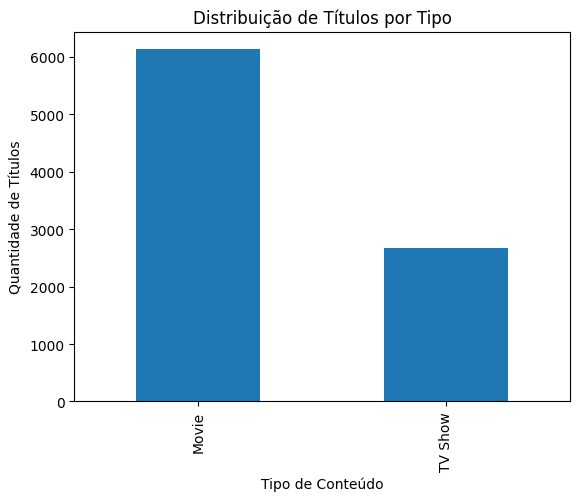

In [10]:
import matplotlib.pyplot as plt

counts = df['type'].value_counts()

plt.figure()
counts.plot(kind='bar')
plt.title('Distribuição de Títulos por Tipo')
plt.xlabel('Tipo de Conteúdo')
plt.ylabel('Quantidade de Títulos')
plt.show()

In [11]:
titles_per_year = df.groupby('year_added').size()
titles_per_year.tail()

year_added
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
dtype: int64

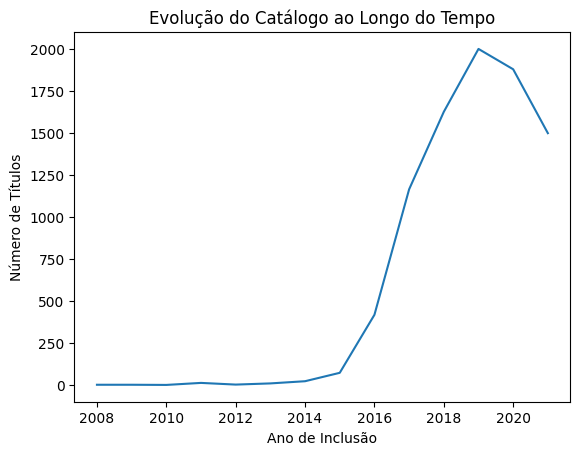

In [12]:
plt.figure()
titles_per_year.plot(kind='line')
plt.title('Evolução do Catálogo ao Longo do Tempo')
plt.xlabel('Ano de Inclusão')
plt.ylabel('Número de Títulos')
plt.show()

In [13]:
year_type = df.groupby(['year_added', 'type']).size().unstack()
year_type.tail()

type,Movie,TV Show
year_added,,
2017.0,839.0,325.0
2018.0,1237.0,388.0
2019.0,1424.0,575.0
2020.0,1284.0,594.0
2021.0,993.0,505.0


<Figure size 640x480 with 0 Axes>

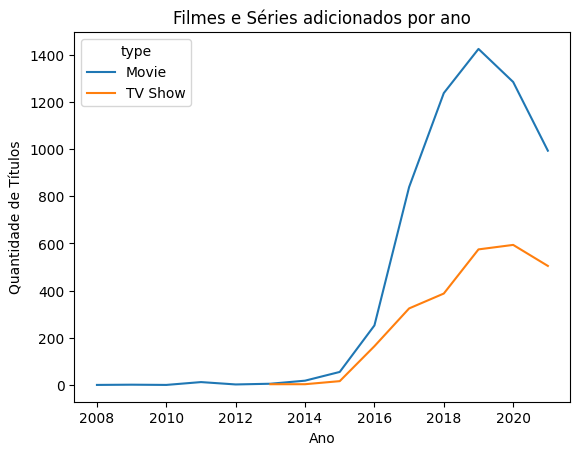

In [14]:
plt.figure()
year_type.plot()
plt.title('Filmes e Séries adicionados por ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Títulos')
plt.show()

In [15]:
countries = df['country'].dropna().str.split(', ').explode()
countries.value_counts().head(10)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

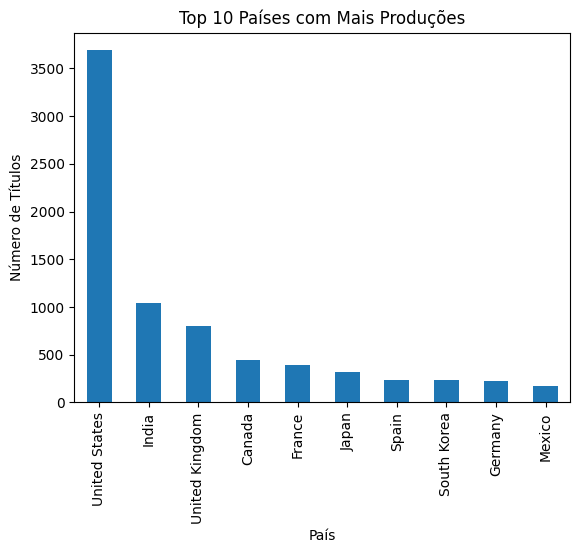

In [16]:
top_countries = countries.value_counts().head(10)

plt.figure()
top_countries.plot(kind='bar')
plt.title('Top 10 Países com Mais Produções')
plt.xlabel('País')
plt.ylabel('Número de Títulos')
plt.show()


In [17]:
genres = df['listed_in'].str.split(', ').explode()
genres.value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

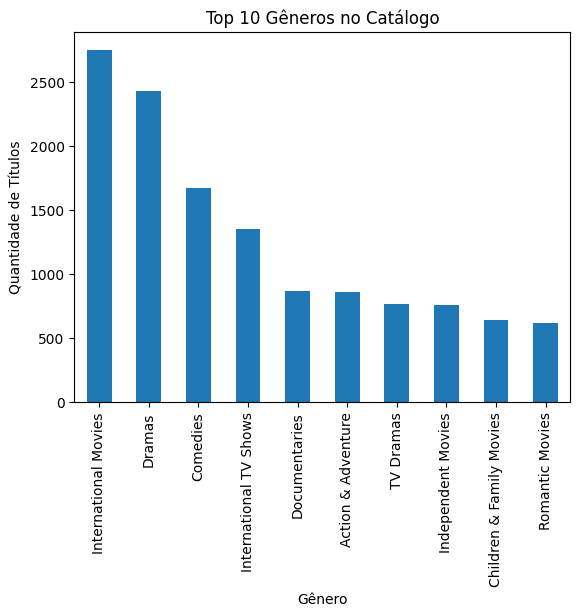

In [18]:
top_genres = genres.value_counts().head(10)

plt.figure()
top_genres.plot(kind='bar')
plt.title('Top 10 Gêneros no Catálogo')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Títulos')
plt.show()

In [19]:
df_final = df[
    ['show_id', 'type', 'title', 'country', 'year_added',
     'release_year', 'rating', 'duration', 'listed_in']
]

In [20]:
df_final.to_csv('../data/processed/netflix_cleaned.csv', index=False)
